## AdaBoost Hyperparameters

AdaBoost has a **small but important set of hyperparameters** that control
model complexity, learning behavior, and sensitivity to noise.
Understanding these is crucial for effective tuning and avoiding overfitting.

---

### 1. `n_estimators`

- Number of weak learners (iterations of boosting).
- Each estimator focuses more on previously misclassified samples.

**Effect:**
- Low value → underfitting  
- High value → better learning, but risk of overfitting (especially with noise)

**Typical range:**  
- 50 to 500 (start small and increase gradually)

---

### 2. `learning_rate`

- Controls how much each weak learner contributes to the final model.
- Scales the weight assigned to each estimator.

**Effect:**
- Smaller learning rate → slower but more stable learning  
- Larger learning rate → faster learning, higher risk of overfitting

**Trade-off:**
- Lower `learning_rate` usually requires higher `n_estimators`

**Typical values:**  
- 0.01, 0.05, 0.1, 0.5, 1.0

---

### 3. `base_estimator` (or `estimator`)

- The weak learner used at each boosting step.
- Default: **Decision Stump** (Decision Tree with `max_depth=1`)

**Effect:**
- Simple base estimator → lower variance, higher bias  
- More complex base estimator → lower bias, higher variance

**Common choices:**
- DecisionTreeClassifier(max_depth=1)  
- DecisionTreeClassifier(max_depth=2 or 3) (use carefully)

---

### 4. `algorithm`

Controls how sample weights are updated.

- `"SAMME"` → Discrete AdaBoost  
- `"SAMME.R"` → Real AdaBoost (uses class probabilities)

**Effect:**
- `SAMME.R` converges faster and is usually preferred  
- Requires base estimator to support probability prediction

---

### 5. `random_state`

- Controls randomness for reproducibility.
- Does not affect model quality, only repeatability.

---

### Hyperparameter Interaction

| Parameter | Controls | Risk if Misused |
|--------|---------|----------------|
| `n_estimators` | Model capacity | Overfitting |
| `learning_rate` | Update strength | Instability |
| `base_estimator` | Model complexity | High variance |
| `algorithm` | Weight update method | Slower convergence |

---

### Tuning Strategy (Practical)

Recommended approach:
1. Start with default base estimator (decision stump)
2. Set `learning_rate` to a small value (0.05 or 0.1)
3. Increase `n_estimators` gradually
4. Monitor validation performance
5. Increase base estimator complexity only if underfitting persists

---

### Common Mistakes

- Using high `learning_rate` with many estimators  
- Using deep trees as base estimators  
- Applying AdaBoost to very noisy datasets  
- Ignoring feature scaling when base estimator is sensitive to scale  

---

### AdaBoost Hyperparameters vs Random Forest

| Aspect | AdaBoost | Random Forest |
|------|---------|---------------|
| Number of key params | Few | Many |
| Sensitivity to tuning | High | Moderate |
| Noise sensitivity | High | Low |

---

### Key Takeaways

- `n_estimators` and `learning_rate` are the most important hyperparameters  
- Smaller learning rates improve stability  
- Decision stumps are usually the best base learners  
- AdaBoost is powerful but sensitive to noise and overfitting  

Careful hyperparameter tuning is essential to unlock the full potential of AdaBoost.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

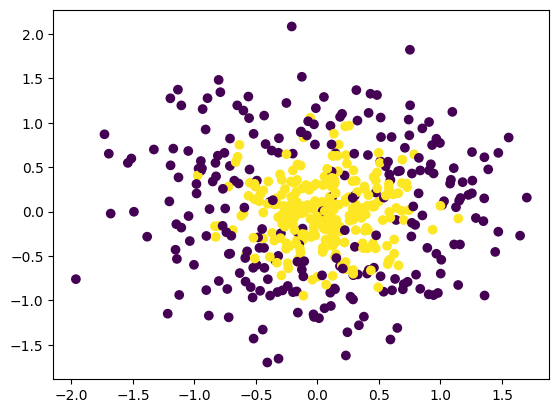

In [3]:
plt.scatter(X[:,0],X[:,1],c=y)

In [4]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

abc = AdaBoostClassifier()

np.mean(cross_val_score(abc,X,y,scoring='accuracy',cv=10))

np.float64(0.812)

In [5]:
abc.fit(X,y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


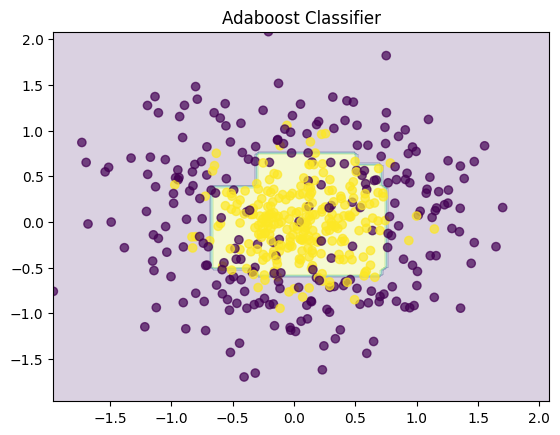

In [7]:
def plot_decision_boundary(clf):
   # plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("Adaboost Classifier")
    plt.show()
    
plot_decision_boundary(abc)

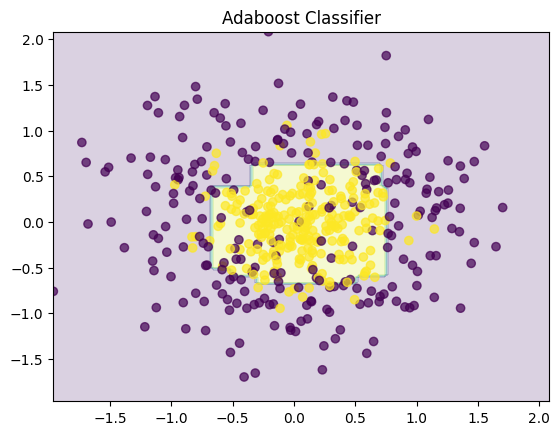

In [8]:
abc = AdaBoostClassifier(n_estimators=1500,learning_rate=0.1)
abc.fit(X,y)
plot_decision_boundary(abc)

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

param_grid = {
    'n_estimators': [10, 50, 100, 200],
    'learning_rate': [0.001, 0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid_result = grid_search.fit(X, y)

print("Best Score:", grid_result.best_score_)
print("Best Params:", grid_result.best_params_)


Best Score: 0.8280000000000001
Best Params: {'learning_rate': 0.1, 'n_estimators': 200}
